## Trabajo Práctico Final - Aprendizaje de Máquina (CEIA)

Integrantes del grupo:
- Bernardo Pablo Eppenstein
- Gonzalo Martín Rodríguez
- Tómas Abrham
 

**Origen de la información:**

El data set que vamos a trabajar es obtenido de https://archive.ics.uci.edu/dataset/421/aps+failure+at+scania+trucks
que contiene 3 archivos aps_failure_test_set.csv, aps_failure_training_set.csv y aps_failure_description.txt

**Contexto**

El conjunto de datos se compone de información recopilada de camiones pesados ​​Scania durante su uso cotidiano. El sistema objeto de estudio es el sistema de aire a presión (APS), el cual genera aire comprimido utilizado para diversas funciones del camión, tales como el frenado y el cambio de marchas. La clase positiva del conjunto de datos comprende los fallos de un componente específico del sistema APS, mientras que la clase negativa incluye camiones con fallos en componentes ajenos a dicho sistema.

El conjunto de entrenamiento contiene un total de 60.000 ejemplos, de los cuales 59.000 pertenecen a la clase negativa y 1.000 a la clase positiva. El conjunto de prueba contiene 16.000 ejemplos. Hay 171 atributos por registro.

Los nombres de los atributos de los datos han sido anonimizados por razones de propiedad. Estos consisten tanto en contadores numéricos individuales como en histogramas formados por intervalos (o *bins*) con diferentes condiciones. Por lo general, los histogramas presentan condiciones de rango abierto en ambos extremos.

**Planteo del problema**

Los distintos mantenimientos tienen diversos costos. El Costo 1 del mantenimiento de un camión sin falla es 10 y el Costo 2 de un camión con falla es 500. Por lo tanto el objetivo es minimizar el costo total asociado a un modelo de predicción, que se calcula de la siguiente manera Costo Total = (Costo 1 * número de instancias 1) + (Costo 2 * número de instancias 2).
Por lo que se observa, el costo 1 es el costo asociado a la revisión innecesaria en un taller de un camión que no va a fallar, multiplicado por la cantidad de instancias 1, y el costo 2 se refiere al costo de no detectar un camión defectuoso, lo cual podría causar una avería, multiplicado por el número de instancias 2.


Cargamos los datos

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
%matplotlib inline

In [22]:
train = pd.read_csv('aps_failure_training_set.csv', skiprows=20, na_values='na')
test = pd.read_csv('aps_failure_test_set.csv', skiprows=20, na_values='na')

In [23]:
train.shape

(60000, 171)

### EDA

In [24]:
test.shape

(16000, 171)

El data set consiste solo de variables numericas.

Descartamos la constante

In [25]:
train.cd_000

0        1209600.0
1        1209600.0
2        1209600.0
3        1209600.0
4        1209600.0
           ...    
59995    1209600.0
59996    1209600.0
59997    1209600.0
59998    1209600.0
59999    1209600.0
Name: cd_000, Length: 60000, dtype: float64

Vemos los valores faltantes por columna

In [26]:
faltantes_por_columna = train.isnull().sum().sort_values(ascending=False)
print(faltantes_por_columna[faltantes_por_columna > 0])


br_000    49264
bq_000    48722
bp_000    47740
bo_000    46333
ab_000    46329
          ...  
by_000      473
ck_000      338
cj_000      338
ci_000      338
bt_000      167
Length: 169, dtype: int64


Como dijimos antes vamos a eliminar la variable constante e imputar los valores faltantes por la mediana, ya que es la que menos hace variar la distribución de la variable en los casos donde la misma es muy asimétrica.


In [27]:
from sklearn.impute import SimpleImputer

# cd_000 es constante (unico valor nulo) -> no aporta info, se descarta
train = train.drop(columns=['cd_000'])
test  = test.drop(columns=['cd_000'])

feature_cols = train.columns.drop('class')
imputer = SimpleImputer(strategy='median')
train[feature_cols] = imputer.fit_transform(train[feature_cols])
test[feature_cols] = imputer.transform(test[feature_cols])


In [28]:
train.shape

(60000, 170)


Verificamos la correlación entre features del data set, para ver si hay correlación fuerte entre algunas variables lo que nos permitiría eliminarlas. Tomamos un umbral de 0.9.


In [29]:
threshold = 0.9

# corremos la correlacion sobre las variables continuas originales, sin 'class'
corr_matrix = train[feature_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# de cada par con |r| > threshold, nos quedamos con una y descartamos la otra
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

print(f'Columnas eliminadas por alta correlacion (> {threshold}): {len(to_drop)} de {len(feature_cols)}')
print(to_drop)

train = train.drop(columns=to_drop)
test  = test.drop(columns=to_drop)

print('shape train:', train.shape, 'shape test:', test.shape)


Columnas eliminadas por alta correlacion (> 0.9): 43 de 169
['am_0', 'an_000', 'ao_000', 'aq_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'bb_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'bt_000', 'bu_000', 'bv_000', 'by_000', 'cc_000', 'cf_000', 'ci_000', 'cn_004', 'cn_005', 'co_000', 'cq_000', 'cs_005', 'dc_000', 'dn_000', 'dp_000', 'dt_000', 'ed_000', 'ee_000', 'ee_001', 'ee_002', 'ee_003', 'ee_004']
shape train: (60000, 127) shape test: (16000, 127)


In [30]:
train.shape

(60000, 127)

In [31]:
test.shape

(16000, 127)

In [32]:
X_train_full = train.drop(columns='class')
y_train_full = train['class'].map({'neg': 0, 'pos': 1})

X_test = test.drop(columns='class')
y_test = test['class'].map({'neg': 0, 'pos': 1})


In [33]:
X_train_full.shape, y_train_full.shape, X_test.shape, y_test.shape

((60000, 126), (60000,), (16000, 126), (16000,))

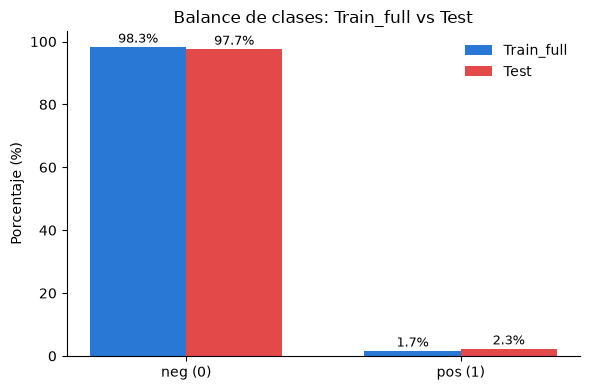

In [34]:
counts_train = y_train_full.value_counts(normalize=True).sort_index() * 100
counts_test  = y_test.value_counts(normalize=True).sort_index() * 100

labels = ['neg (0)', 'pos (1)']
x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
bars_train = ax.bar([i - width/2 for i in x], counts_train.values, width, label='Train_full', color='#2a78d6')
bars_test  = ax.bar([i + width/2 for i in x], counts_test.values, width, label='Test', color='#e34948')

ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Balance de clases: Train_full vs Test')
ax.legend(frameon=False)

for bars in [bars_train, bars_test]:
    for b in bars:
        height = b.get_height()
        ax.annotate(f'{height:.1f}%', xy=(b.get_x() + b.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


Vamos a dividir el X_train_full y el y_train_full en un set de train y otro de validacion

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,  # importante por el desbalance
    random_state=42
)

In [36]:
X_train_full.shape, y_train_full.shape, X_train.shape, y_train.shape, X_val.shape, y_val.shape

((60000, 126), (60000,), (48000, 126), (48000,), (12000, 126), (12000,))

### Vamos a verificar cuáles son las variables con mayor correlación respecto del Target


aa_000    0.536978
ah_000    0.512991
bx_000    0.505529
ap_000    0.503651
ee_005    0.485831
ck_000    0.464198
ag_005    0.448212
cs_004    0.437519
ag_003    0.433050
az_005    0.432062
ba_000    0.430719
ee_006    0.415300
ay_008    0.409810
cn_003    0.406036
cs_003    0.391673
cn_001    0.390680
cs_002    0.372410
ag_004    0.371622
ag_006    0.368423
cn_002    0.367792
dtype: float64


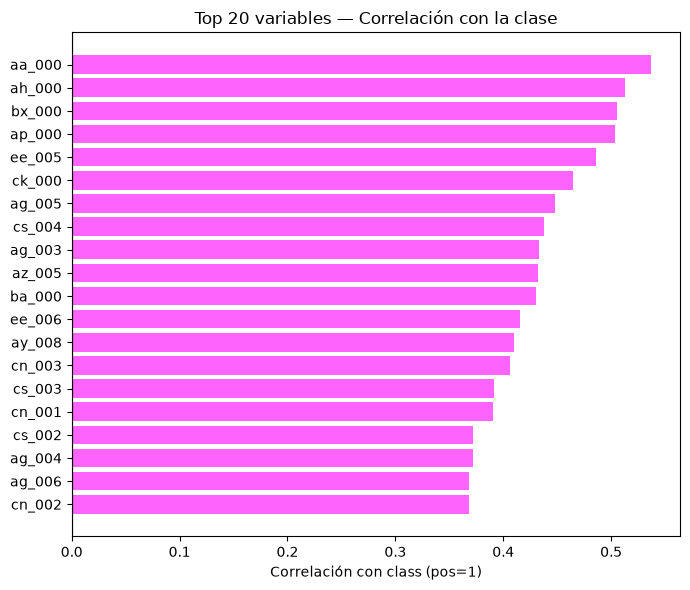

In [37]:
# correlación de cada variable con la clase (point-biserial, ya que la clase es binaria 0/1)
corr_class = X_train_full.corrwith(y_train_full).sort_values(key=lambda s: s.abs(), ascending=False)

top20_class = corr_class.head(20)
print(top20_class)

fig, ax = plt.subplots(figsize=(7, 6))
orden = top20_class.sort_values().index   # para que el gráfico quede ordenado de menor a mayor
valores = top20_class.loc[orden]
colores = ['#ff48fd' if v > 0 else '#007aff' for v in valores]
ax.barh(orden, valores, color=colores, alpha=0.85)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel("Correlación con class (pos=1)")
ax.set_title("Top 20 variables — Correlación con la clase")
plt.tight_layout()
plt.show()


### Vamos a aplicar un BASELINE con la variables de mayor correlacion con el target y tambien con las 5 variables que mejor correlacionan hacer una votacion 

In [38]:
# Baseline heurístico: umbral sobre aa_000 (variable con mayor correlación con la clase), sin entrenar ningún modelo
var_baseline = 'aa_000'

valor_neg = X_train.loc[y_train == 0, var_baseline]
valor_pos = X_train.loc[y_train == 1, var_baseline]
umbral_baseline = (valor_neg.median() + valor_pos.median()) / 2

y_pred_baseline = (X_test[var_baseline] > umbral_baseline).astype(int)


In [39]:
def costo(y_true, y_pred):
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    return fn * 500 + fp * 10


In [40]:
top5 = corr_class.abs().sort_values(ascending=False).head(5).index.tolist()

# umbral por variable: punto medio entre la mediana de la clase neg y la de la clase pos
umbrales_top5 = {}
for var in top5:
    valor_neg = X_train.loc[y_train == 0, var]
    valor_pos = X_train.loc[y_train == 1, var]
    umbrales_top5[var] = (valor_neg.median() + valor_pos.median()) / 2

print(umbrales_top5)

# para cada variable, 1 si supera su umbral, 0 si no
votos = pd.DataFrame({var: (X_test[var] > umbrales_top5[var]).astype(int) for var in top5})
conteo_votos = votos.sum(axis=1)

# predice falla si la mayoría (al menos 3 de 5) de las variables "alarman"
y_pred_baseline5 = (conteo_votos >= 3).astype(int)


{'aa_000': np.float64(300337.0), 'ah_000': np.float64(8957333.0), 'bx_000': np.float64(20649905.5), 'ap_000': np.float64(5375875.0), 'ee_005': np.float64(1432851.0)}


In [41]:
modelos = ["Baseline (umbral aa_000)", "Baseline (voto mayoría top5)"]
preds = [y_pred_baseline, y_pred_baseline5]

df_cmp = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds],
    "Costo": [costo(y_test, yp) for yp in preds],
}, index=pd.Index(modelos))

df_cmp.round(4)


,F1-score,Exactitud balanceada,Precisión,Recall,Costo
Baseline (umbral aa_000),0.5377,0.8635,0.4184,0.752,50420
Baseline (voto mayoría top5),0.5706,0.8917,0.4410,0.808,39840


### *Selección de algoritmos*

Los algoritmos seleccionados para analizar en nuestro modelo de clasificación están orientados principalmente por el fuerte desbalanceo que tenemos en el target. Y ya que de antemano es muy difícil predecir cuál se puede comportar mejor, aunque podemos intuir que posiblemente un ensamble se comporte mejor que un modelo más simple, solo lo vamos a saber corriendo los mismos.
Por lo tanto, de los modelos estudiados decidimos analizar Regresión Logística, SVC, Árboles de clasificación y Random Forest, ya que todos estos modelos tienen el hiperparámetro de balanceo de clases.



 #### Función de costo
 Teniendo en cuenta que nuestra premisa es optimizar el costo de los mantenimiento mal clasificados como los FP y FN, y en los scoring de los modelos están las opciones que busquen por F1, recall y otros tipos de clasificadores también es posible colocar una función. Y creemos que es totalmente óptimo crear una función para que represente nuestro interés buscado.


Definiomos una función de costo.

In [42]:
def costo(y_true, y_pred):
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    return fn * 500 + fp * 10


### Vamos a aplicar Regresión Logística


Vamos a aplicar el modelo regresión logística, por lo que vamos a aplicar GridSearchCV para seleccionar los hiperparámetros del modelo. Además vamos a definir un argumento que utiliza la función de costo para colocar en el scoring.
El modelo también requiere que se haga un escalado de las variables para que la ponderación sea la misma en todas ellas.


In [43]:
from sklearn.metrics import make_scorer

costo_scorer = make_scorer(costo, greater_is_better=False)


In [44]:
from sklearn.metrics import make_scorer

costo_scorer = make_scorer(costo, greater_is_better=False)


##### Búsqueda de hiperparámetros
Vamos a generar un pipeline que haga el escalado de los parámetros y corra el GridSearchCV.
Además agregamos código para que quede registrado el tiempo y la memoria utilizado en correr el modelo . Una forma de medir el costo de correr dicho modelo.


In [46]:
import psutil
import time
import os

clf_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

hyperparams = {
    "model__C": [0.01, 0.1, 1],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
    "model__class_weight": [None, "balanced", {0: 1, 1: 50}]
}

grid = GridSearchCV(clf_logreg,
                    hyperparams,
                    refit=True,
                    cv=5,
                    scoring=costo_scorer,
                    n_jobs=-1)

proceso = psutil.Process(os.getpid())
memoria_antes = proceso.memory_info().rss / (1024 ** 2)   # MB
inicio = time.perf_counter()

grid.fit(X_train, y_train)

fin = time.perf_counter()
memoria_despues = proceso.memory_info().rss / (1024 ** 2)  # MB

print(f"Tiempo de búsqueda (GridSearchCV): {fin - inicio:.2f} segundos")
print(f"Memoria usada: {memoria_despues - memoria_antes:.2f} MB (antes: {memoria_antes:.2f} MB, después: {memoria_despues:.2f} MB)")
print(grid.best_params_)

C:\Users\middlesoft\anaconda3\envs\env_anaconda_shareable\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\middlesoft\anaconda3\envs\env_anaconda_shareable\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Tiempo de búsqueda (GridSearchCV): 919.93 segundos
Memoria usada: -1.66 MB (antes: 387.98 MB, después: 386.32 MB)
{'model__C': 0.01, 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'liblinear'}


In [47]:
grid.best_params_

{'model__C': 0.01,
 'model__class_weight': 'balanced',
 'model__penalty': 'l1',
 'model__solver': 'liblinear'}

Vemos que los hiperparámetros elegidos utilizan class_weight='balanced', para compensar el excesivo desbalance de los resultados. También usa regularización L1, que lo que hace es forzar muchos coeficientes a cero para anular variables que no aportan información. Además observamos que el valor de C es muy pequeño, lo que indica que la regularización es fuerte. Se utilizó el solver liblinear, que soporta regularización L1 y L2, y es el indicado para datasets chicos o medianos y para clasificación binaria.
También vemos que en el scoring se usó costo_scorer, que es una función que prioriza el costo de nuestro problema.

elegidos los parametros corremos el modelo

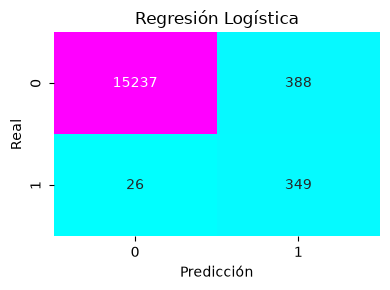

In [48]:
best_logreg = grid.best_estimator_

y_pred = best_logreg.predict(X_test)
cm_logreg = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Regresión Logística")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

Vemos los resultados de las principales métricas.

In [49]:
TN, FP, FN, TP = cm_logreg.ravel()

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print("Regresión Logística")
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {(TPR + TNR) / 2:.4f}")
print(f"Precisión:             {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:                {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-score:              {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Costo total = {FP * 10 + FN * 500:.0f} (FP: {FP}, FN: {FN})")

Regresión Logística
Sensibilidad (Recall): 0.9307
Especificidad:         0.9752
Exactitud balanceada:  0.9529
Precisión:             0.4735
Recall:                0.9307
F1-score:              0.6277
Costo total = 16880 (FP: 388, FN: 26)


Como el modelo corre originalmente con un umbral de corte en 0.5. Vamos a utilizar el set de datos de validación para verificar si hay algún punto de corte que optimice mejor la función de costo.


In [50]:
# 1) Sacamos las probabilidades del modelo sobre la validación
#    predict_proba devuelve 2 columnas (prob de 0 y prob de 1), nos quedamos con la de clase 1 (pos)
probs = grid.best_estimator_.predict_proba(X_val)[:, 1]

# 2) Probamos distintos umbrales y calculamos el costo en cada uno
resultados = []

for umbral in np.arange(0.01, 1.00, 0.05):
    # convertimos probabilidad en predicción 0/1 según el umbral
    y_pred = (probs >= umbral).astype(int)
    
    # contamos falsos negativos y falsos positivos
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    
    # costo de negocio
    costo_i = fn * 500 + fp * 10
    
    resultados.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

# 3) Armamos una tabla para ver todo junto
tabla = pd.DataFrame(resultados)
print(tabla)

# 4) Nos quedamos con el umbral que minimiza el costo
mejor_fila = tabla.loc[tabla['costo'].idxmin()]
print("\nMejor umbral:")
print(mejor_fila)

    umbral  FN     FP   costo
0     0.01   0  11791  117910
1     0.06   1   4036   40860
2     0.11   5   1402   16520
3     0.16   5    892   11420
4     0.21   7    666   10160
5     0.26   7    552    9020
6     0.31   8    479    8790
7     0.36  10    432    9320
8     0.41  12    395    9950
9     0.46  12    359    9590
10    0.51  14    330   10300
11    0.56  16    299   10990
12    0.61  16    278   10780
13    0.66  19    251   12010
14    0.71  20    228   12280
15    0.76  22    210   13100
16    0.81  25    192   14420
17    0.86  28    174   15740
18    0.91  31    149   16990
19    0.96  41    111   21610

Mejor umbral:
umbral       0.31
FN           8.00
FP         479.00
costo     8790.00
Name: 6, dtype: float64


Vamos a afinar la selección del umbral en torno al valor obtenido anteriormente.

In [51]:
# 1) Sacamos las probabilidades del modelo sobre la validación
#    predict_proba devuelve 2 columnas (prob de 0 y prob de 1), nos quedamos con la de clase 1 (pos)
probs = grid.best_estimator_.predict_proba(X_val)[:, 1]

# 2) Probamos distintos umbrales y calculamos el costo en cada uno
resultados = []

for umbral in np.arange(0.26, 0.37, 0.01):
    # convertimos probabilidad en predicción 0/1 según el umbral
    y_pred = (probs >= umbral).astype(int)
    
    # contamos falsos negativos y falsos positivos
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    
    # costo de negocio
    costo_i = fn * 500 + fp * 10
    
    resultados.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

# 3) Armamos una tabla para ver todo junto
tabla = pd.DataFrame(resultados)
print(tabla)

# 4) Nos quedamos con el umbral que minimiza el costo
mejor_fila = tabla.loc[tabla['costo'].idxmin()]
print("\nMejor umbral:")
print(mejor_fila)

    umbral  FN   FP  costo
0     0.26   7  552   9020
1     0.27   7  535   8850
2     0.28   7  520   8700
3     0.29   7  508   8580
4     0.30   8  491   8910
5     0.31   8  479   8790
6     0.32  10  472   9720
7     0.33  10  459   9590
8     0.34  10  442   9420
9     0.35  10  437   9370
10    0.36  10  432   9320

Mejor umbral:
umbral       0.29
FN           7.00
FP         508.00
costo     8580.00
Name: 3, dtype: float64


Seleccionado el mejor umbral de corte del modelo obtenemos nuevamente las métricas con el nuevo umbral de corte.

In [52]:
probs_test = grid.best_estimator_.predict_proba(X_test)[:, 1]
umbral_final = 0.29
y_pred_test = (probs_test >= umbral_final).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
costo_final = fn * 500 + fp * 10

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Costo final en test: {costo_final}")
print(classification_report(y_test, y_pred_test, digits=3))

TN=14997, FP=628, FN=15, TP=360
Costo final en test: 13780
              precision    recall  f1-score   support

           0      0.999     0.960     0.979     15625
           1      0.364     0.960     0.528       375

    accuracy                          0.960     16000
   macro avg      0.682     0.960     0.754     16000
weighted avg      0.984     0.960     0.968     16000



Observamos en las métricas que mejorando el corte del sistema mejoró el costo original de 16880 a 13780.


Vamos a graficar una curva ROC del modelo

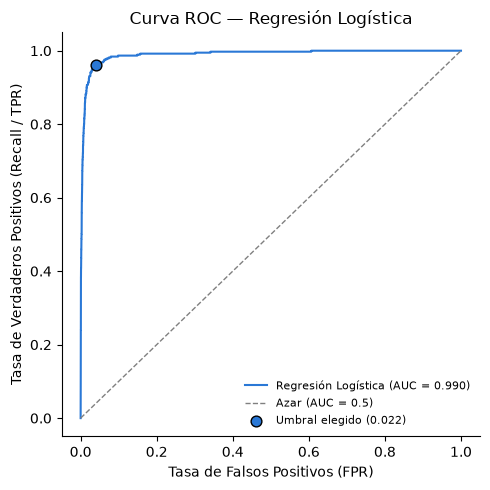

In [53]:
from sklearn.metrics import roc_curve, auc

fpr_log, tpr_log, _ = roc_curve(y_test, probs_test)
auc_log = auc(fpr_log, tpr_log)

tn_l, fp_l, fn_l, tp_l = confusion_matrix(y_test, y_pred_test).ravel()
fpr_op_log, tpr_op_log = fp_l / (fp_l + tn_l), tp_l / (tp_l + fn_l)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_log, tpr_log, color='#2a78d6', label=f'Regresión Logística (AUC = {auc_log:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Azar (AUC = 0.5)')
ax.scatter([fpr_op_log], [tpr_op_log], color='#2a78d6', edgecolor='k', zorder=5, s=60,
           label='Umbral elegido (0.022)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall / TPR)')
ax.set_title('Curva ROC — Regresión Logística')
ax.legend(frameon=False, loc='lower right', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


*Analisis de la features mas significativas*
Vamos a observar las variables que mayor probabilidad aporta para la  ocurrencia de fallas a medida que aumentan su intensidad (color magenta). Y en el caso de las variables (color azul) a medida que aumentan su intesidad la probabilidad de que el camion no falle aumentan

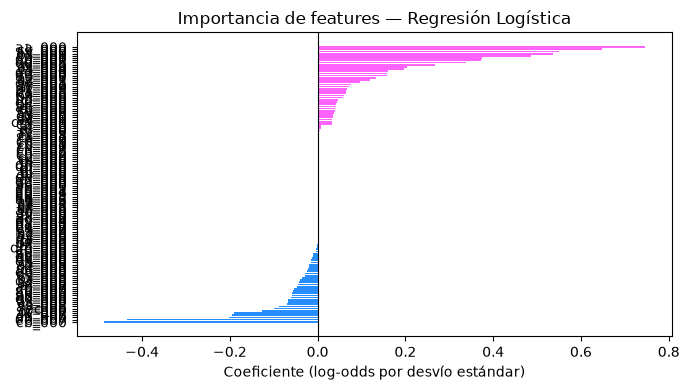

In [54]:
coefs = best_logreg.named_steps['model'].coef_.ravel()
orden = np.argsort(coefs)

fig, ax = plt.subplots(figsize=(7, 4))
colores = ['#ff48fd' if c > 0 else '#007aff' for c in coefs[orden]]
feature_names = X_train.columns
ax.barh(np.array(feature_names)[orden], coefs[orden], color=colores, alpha=0.85)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel("Coeficiente (log-odds por desvío estándar)")
ax.set_title("Importancia de features — Regresión Logística")
plt.tight_layout()
plt.show()

Vamos a afinar un poco mas la clasificacion para ver las variables mas significativas

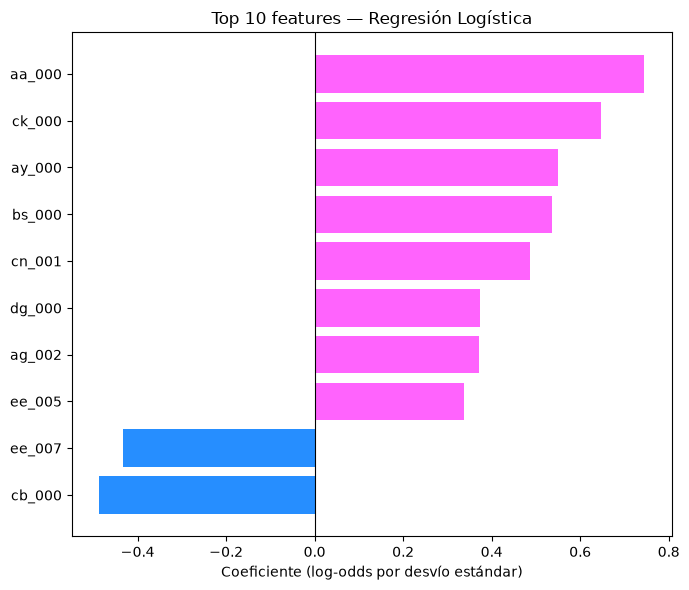

In [55]:
coefs = best_logreg.named_steps['model'].coef_.ravel()
feature_names = X_train.columns

n_top = 10
orden_abs = np.argsort(np.abs(coefs))[-n_top:]   # las n_top con mayor |coeficiente|
orden = orden_abs[np.argsort(coefs[orden_abs])]   # las reordena de menor a mayor para el gráfico

fig, ax = plt.subplots(figsize=(7, 6))
colores = ['#ff48fd' if c > 0 else '#007aff' for c in coefs[orden]]
ax.barh(np.array(feature_names)[orden], coefs[orden], color=colores, alpha=0.85)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel("Coeficiente (log-odds por desvío estándar)")
ax.set_title(f"Top {n_top} features — Regresión Logística")
plt.tight_layout()
plt.show()


#### Vemos una tabla de comparación de resultados modelos ejecutados hasta ahora.


In [56]:
modelos_final = ["Baseline (voto mayoría top5)", "Regresión Logística (umbral 0.29)"]
preds_final = [y_pred_baseline5, y_pred_test]

df_cmp_final = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds_final],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Costo": [costo(y_test, yp) for yp in preds_final],
}, index=pd.Index(modelos_final))

df_cmp_final.round(4)


,F1-score,Exactitud balanceada,Precisión,Recall,Costo
Baseline (voto mayoría top5),0.5706,0.8917,0.4410,0.808,39840
Regresión Logística (umbral 0.29),0.5282,0.9599,0.3644,0.960,13780


### Vamos a aplicar el modelo SVM

Vamos a aplicar el modelo de soporte vector machine. Con las consideraciones generales similares a las tenida en cuenta en el caso de Regrsion Logitica.

Antes de entrenar el data set completo y esto lleva mucho tiempo, vamos a realizar un muestreo del data set el con el cual vamos a seleccionar la aproximacion de  hiperparametros a utilizar.

In [57]:
X_train_muestra, _, y_train_muestra, _ = train_test_split(
    X_train, y_train,
    train_size=8000,
    stratify=y_train,
    random_state=42
)


In [58]:
X_train_muestra.shape, y_train_muestra.shape

((8000, 126), (8000,))

Vamos a aplicar un pipline de la muestra que hacer primero el escalado de las variables porque en este modelo si mide distancias y necesita que las magintudes esten todas escaladas. Ademas utilizar GridserachCV para la selección de hiperparámetros. Obviamente que también utilizamos la costo_scorer en el scoring.

In [60]:
from sklearn.svm import SVC

clf_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC())
])

hiper_svm = {
    "model__kernel": ["linear", "rbf"],
    "model__C": [0.05, 0.1, 0.2],
    "model__gamma": ["scale", "auto"],   # se ignora automáticamente si kernel='linear'
    "model__class_weight": ["balanced"],
}


grid_svm = GridSearchCV(clf_svm,
                         hiper_svm,
                         refit=True,
                         cv=5,
                         scoring=costo_scorer,
                         n_jobs=-1)
grid_svm.fit(X_train_muestra, y_train_muestra)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...del', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.05, 0.1, ...], 'model__class_weight': ['balanced'], 'model__gamma': ['scale', 'auto'], 'model__kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(c...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20

In [61]:
grid_svm.best_params_

{'model__C': 0.05,
 'model__class_weight': 'balanced',
 'model__gamma': 'scale',
 'model__kernel': 'rbf'}

Vemos que los hiperparámetros elegidos utilizan class_weight='balanced', al igual que en los demás modelos, para compensar el excesivo desbalance de clases del problema. Se seleccionó el kernel rbf, lo que indica que la frontera de separación entre camiones con falla y sin falla no es puramente lineal,  El valor de gamma='scale' deja que scikit-learn calcule automáticamente, a partir de la varianza de las variables ya escaladas, hasta dónde llega la influencia de cada punto de entrenamiento sobre la frontera. Por último, C=0.1 es un valor relativamente bajo, lo que indica que el modelo prioriza un margen más amplio  por sobre clasificar perfectamente cada ejemplo de entrenamiento.

Ahora con esta seleccion de hiperparámetros vamos a correr el train del modelo completo.

Vamos a agregar codigo tambien para medir el tiempo utilizado en el entrenamiento y el costo de computo utilizado

In [62]:
clf_svm_final = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(C=0.1, kernel='rbf', gamma='scale', class_weight='balanced', probability=True, random_state=42))
])



In [63]:
import time
import psutil
import os

proceso = psutil.Process(os.getpid())
memoria_antes = proceso.memory_info().rss / (1024 ** 2)   # MB
inicio = time.perf_counter()

clf_svm_final.fit(X_train, y_train)

fin = time.perf_counter()
memoria_despues = proceso.memory_info().rss / (1024 ** 2)  # MB

print(f"Tiempo de entrenamiento: {fin - inicio:.2f} segundos")
print(f"Memoria usada: {memoria_despues - memoria_antes:.2f} MB (antes: {memoria_antes:.2f} MB, después: {memoria_despues:.2f} MB)")


C:\Users\middlesoft\anaconda3\envs\env_anaconda_shareable\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Tiempo de entrenamiento: 431.91 segundos
Memoria usada: -0.57 MB (antes: 405.59 MB, después: 405.02 MB)


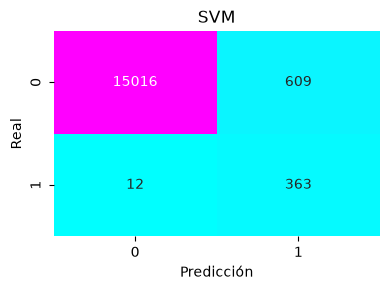

SVM (umbral 0.5, sin ajustar)
Sensibilidad (Recall): 0.9680
Especificidad:         0.9610
Exactitud balanceada:  0.9645
Precisión:             0.3735
Recall:                0.9680
F1-score:              0.5390
Costo total = 12090 (FP: 609, FN: 12)


In [64]:
y_pred_svm = clf_svm_final.predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("SVM")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm_svm.ravel()
TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print("SVM (umbral 0.5, sin ajustar)")
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {(TPR + TNR) / 2:.4f}")
print(f"Precisión:             {precision_score(y_test, y_pred_svm, zero_division=0):.4f}")
print(f"Recall:                {recall_score(y_test, y_pred_svm, zero_division=0):.4f}")
print(f"F1-score:              {f1_score(y_test, y_pred_svm, zero_division=0):.4f}")
print(f"Costo total = {costo(y_test, y_pred_svm)} (FP: {FP}, FN: {FN})")


Observamos los resultados de las métricas obtenidas

Ahora vamos a probar ajustar el umbal de 0,5 a ver si mejora incluso mas el ajuste para optimizar el costo. Esta prueba la vamos a hacer con paquete de validación.

In [65]:
probs_svm = clf_svm_final.predict_proba(X_val)[:, 1]

resultados_svm = []
for umbral in np.arange(0.05, 1.00, 0.05):
    y_pred = (probs_svm >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_svm.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

tabla_svm = pd.DataFrame(resultados_svm)
print(tabla_svm)

mejor_fila_svm = tabla_svm.loc[tabla_svm['costo'].idxmin()]
print("\nMejor umbral SVM (barrido grueso):")
print(mejor_fila_svm)


    umbral   FN   FP  costo
0     0.05    8  451   8510
1     0.10    9  382   8320
2     0.15   11  319   8690
3     0.20   11  283   8330
4     0.25   13  245   8950
5     0.30   17  192  10420
6     0.35   87   73  44230
7     0.40  124   48  62480
8     0.45  142   38  71380
9     0.50  175   33  87830
10    0.55  180   29  90290
11    0.60  183   21  91710
12    0.65  188   20  94200
13    0.70  189   18  94680
14    0.75  192   12  96120
15    0.80  193    9  96590
16    0.85  194    5  97050
17    0.90  196    3  98030
18    0.95  198    1  99010

Mejor umbral SVM (barrido grueso):
umbral       0.1
FN           9.0
FP         382.0
costo     8320.0
Name: 1, dtype: float64


Queremos hacer zoom en el umbral 0,35 que cae de golpe los FN a pesar que no es el punto de menor costo hay alguno evento que ocurre que fallen muchos camiones en ese punto.

In [66]:
resultados_svm_zoom = []
for umbral in np.arange(0.25, 0.36, 0.01):
    y_pred = (probs_svm >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_svm_zoom.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

pd.DataFrame(resultados_svm_zoom)


,umbral,FN,FP,costo
0,0.25,13,245,8950
1,0.26,13,238,8880
2,0.27,15,229,9790
3,0.28,16,219,10190
4,0.29,16,204,10040
5,0.30,17,192,10420
6,0.31,18,179,10790
7,0.32,19,168,11180
8,0.33,21,161,12110
9,0.34,27,140,14900


Graficamos los valores obtenidos

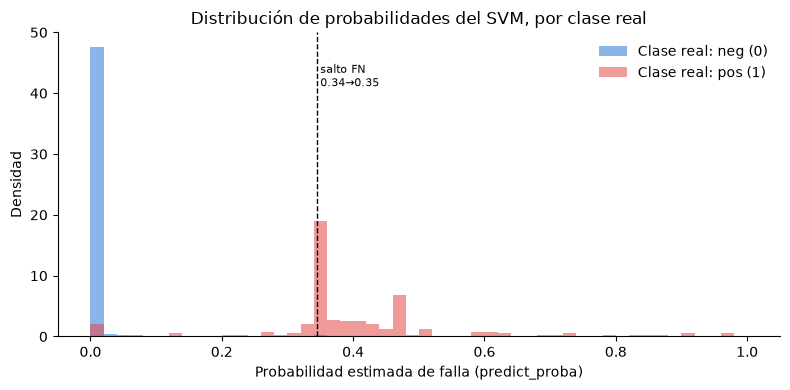

In [67]:
fig, ax = plt.subplots(figsize=(8, 4))

bins = np.arange(0, 1.02, 0.02)

ax.hist(probs_svm[y_val == 0], bins=bins, density=True, alpha=0.55,
        color='#2a78d6', label='Clase real: neg (0)')
ax.hist(probs_svm[y_val == 1], bins=bins, density=True, alpha=0.55,
        color='#e34948', label='Clase real: pos (1)')

ax.axvline(0.345, color='k', linestyle='--', linewidth=1)
ax.text(0.35, ax.get_ylim()[1]*0.9, 'salto FN\n0.34→0.35', fontsize=8, va='top')

ax.set_xlabel('Probabilidad estimada de falla (predict_proba)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de probabilidades del SVM, por clase real')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

En el grafico se muesta lo que creiamos ese umbral de probabilidades ocurre algun evento/os en particular que hace que muchos camiones fallen.

Ahora vamos a afinar los umbrales para ver si podemos mejorar el desempeño del costo

In [68]:
resultados_svm_fino = []
for umbral in np.arange(0.05, 0.21, 0.01):
    y_pred = (probs_svm >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_svm_fino.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

tabla_svm_fino = pd.DataFrame(resultados_svm_fino)
print(tabla_svm_fino)

mejor_fila_svm_fino = tabla_svm_fino.loc[tabla_svm_fino['costo'].idxmin()]
print("\nMejor umbral SVM (barrido fino):")
print(mejor_fila_svm_fino)


    umbral  FN   FP  costo
0     0.05   8  451   8510
1     0.06   8  429   8290
2     0.07   9  411   8610
3     0.08   9  397   8470
4     0.09   9  391   8410
5     0.10   9  382   8320
6     0.11   9  368   8180
7     0.12   9  356   8060
8     0.13  10  345   8450
9     0.14  11  330   8800
10    0.15  11  319   8690
11    0.16  11  311   8610
12    0.17  11  307   8570
13    0.18  11  298   8480
14    0.19  11  292   8420
15    0.20  11  283   8330

Mejor umbral SVM (barrido fino):
umbral       0.12
FN           9.00
FP         356.00
costo     8060.00
Name: 7, dtype: float64


Con el mejor umbral seleccionado ahora lo corremos contra el paquete de test

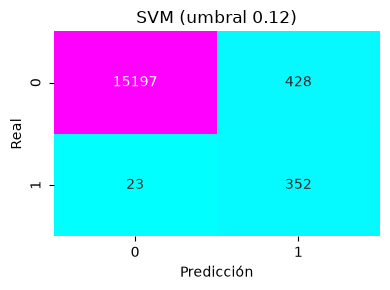

TN=15197, FP=428, FN=23, TP=352
Costo final SVM en test: 15780
              precision    recall  f1-score   support

           0      0.998     0.973     0.985     15625
           1      0.451     0.939     0.610       375

    accuracy                          0.972     16000
   macro avg      0.725     0.956     0.797     16000
weighted avg      0.986     0.972     0.977     16000



In [69]:
probs_svm_test = clf_svm_final.predict_proba(X_test)[:, 1]
umbral_final_svm = 0.12
y_pred_svm_test = (probs_svm_test >= umbral_final_svm).astype(int)

cm_svm_test = confusion_matrix(y_test, y_pred_svm_test)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_svm_test, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("SVM (umbral 0.12)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_svm_test.ravel()
costo_final_svm = fn * 500 + fp * 10

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Costo final SVM en test: {costo_final_svm}")
print(classification_report(y_test, y_pred_svm_test, digits=3))



Observamos los resultados de las métricas obtenidas. Vemos que la metrica mas importante que es el costo esta por encima del obtenido en Regresión Logistica.

Por ultimo graficamos la curva ROC del modelo

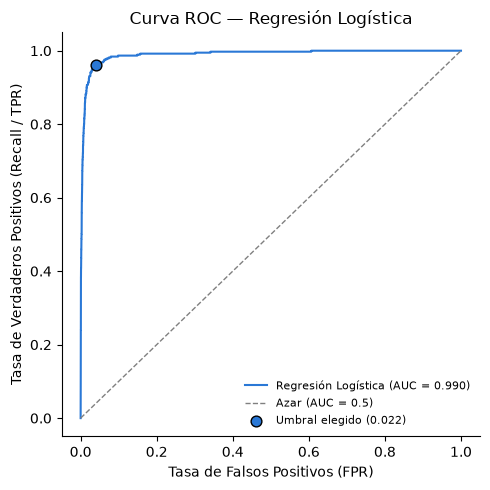

In [70]:
from sklearn.metrics import roc_curve, auc

fpr_log, tpr_log, _ = roc_curve(y_test, probs_test)
auc_log = auc(fpr_log, tpr_log)

tn_l, fp_l, fn_l, tp_l = confusion_matrix(y_test, y_pred_test).ravel()
fpr_op_log, tpr_op_log = fp_l / (fp_l + tn_l), tp_l / (tp_l + fn_l)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_log, tpr_log, color='#2a78d6', label=f'Regresión Logística (AUC = {auc_log:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Azar (AUC = 0.5)')
ax.scatter([fpr_op_log], [tpr_op_log], color='#2a78d6', edgecolor='k', zorder=5, s=60,
           label='Umbral elegido (0.022)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall / TPR)')
ax.set_title('Curva ROC — Regresión Logística')
ax.legend(frameon=False, loc='lower right', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


#### Ahora vamos a hacer una comparación de los modelos que se fueron utilizando.

In [71]:
modelos_final = ["Baseline (voto mayoría top5)", "Regresión Logística (umbral 0.29)", "SVM (umbral 0.12)"]
preds_final = [y_pred_baseline5, y_pred_test, y_pred_svm_test]

df_cmp_final = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds_final],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Costo": [costo(y_test, yp) for yp in preds_final],
}, index=pd.Index(modelos_final))

df_cmp_final.round(4)


,F1-score,Exactitud balanceada,Precisión,Recall,Costo
Baseline (voto mayoría top5),0.5706,0.8917,0.4410,0.8080,39840
Regresión Logística (umbral 0.29),0.5282,0.9599,0.3644,0.9600,13780
SVM (umbral 0.12),0.6095,0.9556,0.4513,0.9387,15780


Observamos que por el momento el mejor modelo es el de regresión logistica. Al final de la corrida de todos los modelos se hara un análisis mas exautivos de los resultados obtenidos.

##### *Calibración*
Conclusión de porque nosotros no necesitamos calibrar nuestro modelo. Como el objetivo que nosotros buscamos es optimizar la funcion de costo, el valor de predict_proba que nosotros movemos es para optimizar el corte de nuestro modelo y mejorar la clasificacion. Basicamente no usamos en ninguna caso el predict_proba como una magnitud en si misma, por ejemplo "estimar el porcentaje de la flota que va a fallar", en ese caso si deberiamos calibrar el valor.
En ambos casos la calibracion es mala porque en ambos modelos se utilizo la funcion costo_scorer y ademas se utilizo class_weight='balanced' y esto hace que el modelo entrene como si las clases estuvieran mas equilibradas de lo que lo estan realmente.

Graficamos las curvas de calibracion de ambos modelos, solo para observarlas pero en nuestro caso no es de utilidad para nuestro problema.

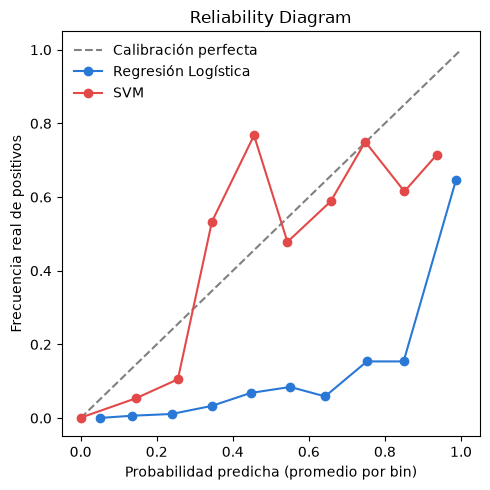

Brier score logreg: 0.024890473934343404
Brier score SVM: 0.012452035217399786


In [72]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

frac_pos_log, mean_pred_log = calibration_curve(y_test, probs_test, n_bins=10)
frac_pos_svm, mean_pred_svm = calibration_curve(y_test, probs_svm_test, n_bins=10)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Calibración perfecta')
ax.plot(mean_pred_log, frac_pos_log, marker='o', color='#2a78d6', label='Regresión Logística')
ax.plot(mean_pred_svm, frac_pos_svm, marker='o', color='#e34948', label='SVM')
ax.set_xlabel('Probabilidad predicha (promedio por bin)')
ax.set_ylabel('Frecuencia real de positivos')
ax.set_title('Reliability Diagram')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print("Brier score logreg:", brier_score_loss(y_test, probs_test))
print("Brier score SVM:", brier_score_loss(y_test, probs_svm_test))

#### Arboles de clasificacion

En este tipo de modelo no necesitamos escalar los valores de los features. Asi que vamos a hacer una seleccion de hiperparametros con GridsearchCV para seleccionar los mejores hiperparametros

Como vemos la funcion de scoring vamos a usar nuevamente la funcion de costo de nuestro problema.

In [73]:
from sklearn.tree import DecisionTreeClassifier

hiper_tree = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "class_weight": [None, "balanced"],
}

grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42),
                          hiper_tree,
                          refit=True,
                          cv=5,
                          scoring=costo_scorer,
                          n_jobs=-1)
grid_tree.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(c...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support f

In [74]:
grid_tree.best_params_


{'class_weight': 'balanced',
 'max_depth': 3,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

Vamos a volver a entrenar los parametros ya que max_depth quedo en el valor minio de 3 que era lo que habiamos puestos como piso de profundidad. Tambien agregamos a script para medir tiempo y memoria utilizada para la selección de hiperparámetros.

In [75]:

hiper_tree = {
    "max_depth": [1, 2, 3, 4, 5],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "class_weight": [None, "balanced"],
}

grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42),
                          hiper_tree,
                          refit=True,
                          cv=5,
                          scoring=costo_scorer,
                          n_jobs=-1)

proceso = psutil.Process(os.getpid())
memoria_antes = proceso.memory_info().rss / (1024 ** 2)   # MB
inicio = time.perf_counter()

grid_tree.fit(X_train, y_train)

fin = time.perf_counter()
memoria_despues = proceso.memory_info().rss / (1024 ** 2)  # MB

print(f"Tiempo de búsqueda (GridSearchCV): {fin - inicio:.2f} segundos")
print(f"Memoria usada: {memoria_despues - memoria_antes:.2f} MB (antes: {memoria_antes:.2f} MB, después: {memoria_despues:.2f} MB)")
print(grid_tree.best_params_)


Tiempo de búsqueda (GridSearchCV): 125.74 segundos
Memoria usada: -0.43 MB (antes: 457.23 MB, después: 456.80 MB)
{'class_weight': 'balanced', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}


Vemos que los hiperparámetros elegidos utilizan class_weight='balanced', siguiendo el mismo patrón que en los demás modelos. El max_depth=4 muestra que el árbol no necesita mucha profundidad para capturar la separación entre camiones con falla y sin falla. Por último, min_samples_leaf=1 y min_samples_split=2 quedaron en sus valores por defecto, los menos restrictivos posibles: como la profundidad ya está bastante limitada, no hace falta que estos otros parámetros aporten regularización adicional.



Vamos a entrenar el paquete de test y ver los resultados obtenidos

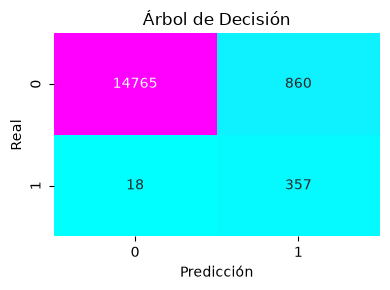

Árbol de Decisión (umbral 0.5, sin ajustar)
Sensibilidad (Recall): 0.9520
Especificidad:         0.9450
Exactitud balanceada:  0.9485
Precisión:             0.2933
Recall:                0.9520
F1-score:              0.4485
Costo total = 17600 (FP: 860, FN: 18)


In [76]:
best_tree = grid_tree.best_estimator_

y_pred_tree = best_tree.predict(X_test)
cm_tree = confusion_matrix(y_test, y_pred_tree)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Árbol de Decisión")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm_tree.ravel()
TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print("Árbol de Decisión (umbral 0.5, sin ajustar)")
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {(TPR + TNR) / 2:.4f}")
print(f"Precisión:             {precision_score(y_test, y_pred_tree, zero_division=0):.4f}")
print(f"Recall:                {recall_score(y_test, y_pred_tree, zero_division=0):.4f}")
print(f"F1-score:              {f1_score(y_test, y_pred_tree, zero_division=0):.4f}")
print(f"Costo total = {costo(y_test, y_pred_tree)} (FP: {FP}, FN: {FN})")


Vamos a utilzar el set de validacion para verificar cual umbral de p_proba mejora el trade off para la funciona de costo que tenemos

In [77]:
probs_tree = best_tree.predict_proba(X_val)[:, 1]
print(f"Valores distintos de probabilidad: {np.unique(probs_tree)}")

resultados_tree = []
for umbral in np.arange(0.05, 1.00, 0.05):
    y_pred = (probs_tree >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_tree.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

tabla_tree = pd.DataFrame(resultados_tree)
print(tabla_tree)

mejor_fila_tree = tabla_tree.loc[tabla_tree['costo'].idxmin()]
print("\nMejor umbral árbol:")
print(mejor_fila_tree)


Valores distintos de probabilidad: [0.         0.01930673 0.15580986 0.19281046 0.25877193 0.53881279
 0.76623377 0.80902518 0.84841222 0.92367906 0.9661957  0.97520661]
    umbral  FN    FP  costo
0     0.05   6  1044  13440
1     0.10   6  1044  13440
2     0.15   6  1044  13440
3     0.20   8   747  11470
4     0.25   8   747  11470
5     0.30   8   699  10990
6     0.35   8   699  10990
7     0.40   8   699  10990
8     0.45   8   699  10990
9     0.50   8   699  10990
10    0.55   8   675  10750
11    0.60   8   675  10750
12    0.65   8   675  10750
13    0.70   8   675  10750
14    0.75   8   675  10750
15    0.80   8   659  10590
16    0.85  25   389  16390
17    0.90  25   389  16390
18    0.95  25   373  16230

Mejor umbral árbol:
umbral        0.8
FN            8.0
FP          659.0
costo     10590.0
Name: 15, dtype: float64


Ahora vamos a correr el data set de test con p_proba modificado el umbal a 0,8

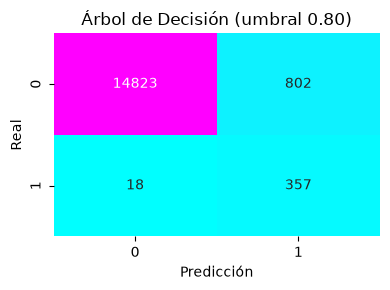

TN=14823, FP=802, FN=18, TP=357
Costo final árbol en test: 17020
              precision    recall  f1-score   support

           0      0.999     0.949     0.973     15625
           1      0.308     0.952     0.465       375

    accuracy                          0.949     16000
   macro avg      0.653     0.950     0.719     16000
weighted avg      0.983     0.949     0.961     16000



In [78]:
probs_tree_test = best_tree.predict_proba(X_test)[:, 1]
umbral_final_tree = 0.80
y_pred_tree_test = (probs_tree_test >= umbral_final_tree).astype(int)

cm_tree_test = confusion_matrix(y_test, y_pred_tree_test)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_tree_test, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Árbol de Decisión (umbral 0.80)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_tree_test.ravel()
costo_final_tree = fn * 500 + fp * 10

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Costo final árbol en test: {costo_final_tree}")
print(classification_report(y_test, y_pred_tree_test, digits=3))


Observamos los resultados obtenidos y vemos que la métrica de costo no mejora la de regresión Logística que es la mejor hasta ahora.

Vamos a graficar la curva ROC

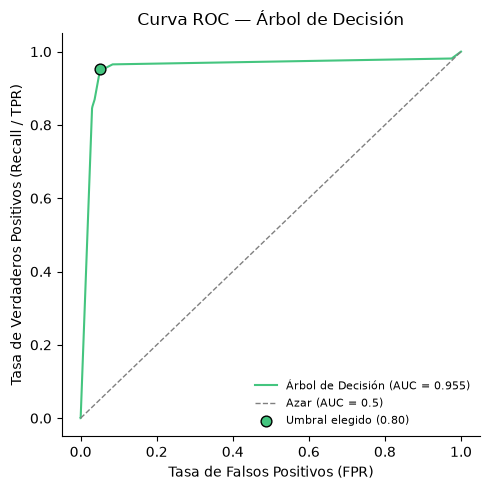

In [79]:
fpr_tree, tpr_tree, _ = roc_curve(y_test, probs_tree_test)
auc_tree = auc(fpr_tree, tpr_tree)

tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_tree_test).ravel()
fpr_op_tree, tpr_op_tree = fp_t / (fp_t + tn_t), tp_t / (tp_t + fn_t)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_tree, tpr_tree, color='#44c57f', label=f'Árbol de Decisión (AUC = {auc_tree:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Azar (AUC = 0.5)')
ax.scatter([fpr_op_tree], [tpr_op_tree], color='#44c57f', edgecolor='k', zorder=5, s=60,
           label='Umbral elegido (0.80)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall / TPR)')
ax.set_title('Curva ROC — Árbol de Decisión')
ax.legend(frameon=False, loc='lower right', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


#### Por ultimo agregamos una tabla comparativa de los modelos utilizados

In [80]:
modelos_final = ["Baseline (voto mayoría top5)", "Regresión Logística (umbral 0.29)", "SVM (umbral 0.12)", "Árbol de Decisión (umbral 0.80)"]
preds_final = [y_pred_baseline5, y_pred_test, y_pred_svm_test, y_pred_tree_test]

df_cmp_final = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds_final],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Costo": [costo(y_test, yp) for yp in preds_final],
}, index=pd.Index(modelos_final))

df_cmp_final.round(4)


,F1-score,Exactitud balanceada,Precisión,Recall,Costo
Baseline (voto mayoría top5),0.5706,0.8917,0.4410,0.8080,39840
Regresión Logística (umbral 0.29),0.5282,0.9599,0.3644,0.9600,13780
SVM (umbral 0.12),0.6095,0.9556,0.4513,0.9387,15780
Árbol de Decisión (umbral 0.80),0.4654,0.9503,0.3080,0.9520,17020


#### Random Forest

Vamos a seleccionar los hiperparametos para este modelo con GridsearchCV. Manteniendo los mismos principio que árbol de clasificación. También se agrega código para medir tiempo y memoría utilizada.

In [81]:
from sklearn.ensemble import RandomForestClassifier

hiper_rf = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8, None],
    "min_samples_leaf": [1, 5],
    "class_weight": [None, "balanced", "balanced_subsample"],
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                        hiper_rf,
                        refit=True,
                        cv=5,
                        scoring=costo_scorer,
                        n_jobs=-1)

proceso = psutil.Process(os.getpid())
memoria_antes = proceso.memory_info().rss / (1024 ** 2)
inicio = time.perf_counter()

grid_rf.fit(X_train, y_train)

fin = time.perf_counter()
memoria_despues = proceso.memory_info().rss / (1024 ** 2)

print(f"Tiempo de búsqueda (GridSearchCV): {fin - inicio:.2f} segundos")
print(f"Memoria usada: {memoria_despues - memoria_antes:.2f} MB (antes: {memoria_antes:.2f} MB, después: {memoria_despues:.2f} MB)")
print(grid_rf.best_params_)


Tiempo de búsqueda (GridSearchCV): 914.13 segundos
Memoria usada: 8.72 MB (antes: 453.42 MB, después: 462.14 MB)
{'class_weight': 'balanced', 'max_depth': 6, 'min_samples_leaf': 5, 'n_estimators': 100}


Como varios hiperparametros cayeron en los bordes de las opciones de prueba. Vamos a correrlo de nuevos con nuevos valores de hiperparametros, solo vamos a dejar fijo el class_weight+'balanced' que ya quedo definido.

In [82]:
hiper_rf_v2 = {
    "n_estimators": [50, 100, 150],
    "max_depth": [2, 3, 4, 5],
    "min_samples_leaf": [5, 10],
    "class_weight": ["balanced"],
}

grid_rf_v2 = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=1),
                           hiper_rf_v2,
                           refit=True,
                           cv=5,
                           scoring=costo_scorer,
                           n_jobs=-1)

proceso = psutil.Process(os.getpid())
memoria_antes = proceso.memory_info().rss / (1024 ** 2)
inicio = time.perf_counter()

grid_rf_v2.fit(X_train, y_train)

fin = time.perf_counter()
memoria_despues = proceso.memory_info().rss / (1024 ** 2)

print(f"Tiempo de búsqueda (GridSearchCV): {fin - inicio:.2f} segundos")
print(f"Memoria usada: {memoria_despues - memoria_antes:.2f} MB (antes: {memoria_antes:.2f} MB, después: {memoria_despues:.2f} MB)")
print(grid_rf_v2.best_params_)


Tiempo de búsqueda (GridSearchCV): 133.97 segundos
Memoria usada: -5.71 MB (antes: 462.12 MB, después: 456.41 MB)
{'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 50}


Volvemos a correrlo nuevamente ya que por ejemplo el parámetro de max_depth tambien esta en el límite de las opciones ofrecidas para probar

In [ ]:
hiper_rf_v3 = {
    "n_estimators": [150, 200, 300],
    "max_depth": [5, 6, 8, 10],
    "min_samples_leaf": [10, 15, 20],
    "class_weight": ["balanced"],
}

grid_rf_v3 = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=1),
                           hiper_rf_v3,
                           refit=True,
                           cv=5,
                           scoring=costo_scorer,
                           n_jobs=-1)

proceso = psutil.Process(os.getpid())
memoria_antes = proceso.memory_info().rss / (1024 ** 2)
inicio = time.perf_counter()

grid_rf_v3.fit(X_train, y_train)

fin = time.perf_counter()
memoria_despues = proceso.memory_info().rss / (1024 ** 2)

print(f"Tiempo de búsqueda (GridSearchCV): {fin - inicio:.2f} segundos")
print(f"Memoria usada: {memoria_despues - memoria_antes:.2f} MB (antes: {memoria_antes:.2f} MB, después: {memoria_despues:.2f} MB)")
print(grid_rf_v3.best_params_)


"Vamos a analizar los hiperparámetros seleccionados. class_weight='balanced', al igual que en todos los modelos, se utiliza para compensar el excesivo desbalance que tiene nuestro set de datos. Con max_depth=5 vemos que el modelo no necesita mucha profundidad para capturar la separación de resultados. El min_samples_leaf=10 es bastante restrictivo, evita que los árboles creen hojas muy específicas. n_estimators=150 es una cantidad de árboles intermedia, no muy chica pero tampoco excesivamente grande (lo cual implicaría un costo computacional mayor). También usamos scoring=costo_scorer, que es nuestra función de costo del problema."

In [ ]:
best_rf = grid_rf_v3.best_estimator_

y_pred_rf = best_rf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Random Forest")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm_rf.ravel()
TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print("Random Forest (umbral 0.5, sin ajustar)")
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {(TPR + TNR) / 2:.4f}")
print(f"Precisión:             {precision_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"Recall:                {recall_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"F1-score:              {f1_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"Costo total = {costo(y_test, y_pred_rf)} (FP: {FP}, FN: {FN})")


Vamos a probar con el set de validación modificar el umbral para ver si mejora el costo

In [ ]:
probs_rf = best_rf.predict_proba(X_val)[:, 1]

resultados_rf = []
for umbral in np.arange(0.01, 1.00, 0.05):
    y_pred = (probs_rf >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_rf.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

tabla_rf = pd.DataFrame(resultados_rf)
print(tabla_rf)

mejor_fila_rf = tabla_rf.loc[tabla_rf['costo'].idxmin()]
print("\nMejor umbral Random Forest (barrido amplio):")
print(mejor_fila_rf)


Hacemos un ajuste fino del umbral

In [ ]:
resultados_rf_fino = []
for umbral in np.arange(0.41, 0.62, 0.01):
    y_pred = (probs_rf >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_rf_fino.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

tabla_rf_fino = pd.DataFrame(resultados_rf_fino)
print(tabla_rf_fino)

mejor_fila_rf_fino = tabla_rf_fino.loc[tabla_rf_fino['costo'].idxmin()]
print("\nMejor umbral Random Forest (barrido fino):")
print(mejor_fila_rf_fino)


Un dato importante para destacar es que el umbral que mejor costo nos da haciendo el ajuste fino es el mismo umbral que el modelo toma por defecto en 0.5.

In [ ]:
probs_rf_test = best_rf.predict_proba(X_test)[:, 1]
umbral_final_rf = 0.50
y_pred_rf_test = (probs_rf_test >= umbral_final_rf).astype(int)

cm_rf_test = confusion_matrix(y_test, y_pred_rf_test)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_rf_test, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Random Forest (umbral 0.50)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_rf_test.ravel()
costo_final_rf = fn * 500 + fp * 10

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Costo final Random Forest en test: {costo_final_rf}")
print(classification_report(y_test, y_pred_rf_test, digits=3))


Observamos los resultados obtenidos, en este modelo si se mejora el costo asociado.

In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, probs_rf_test)
auc_rf = auc(fpr_rf, tpr_rf)

tn_r, fp_r, fn_r, tp_r = confusion_matrix(y_test, y_pred_rf_test).ravel()
fpr_op_rf, tpr_op_rf = fp_r / (fp_r + tn_r), tp_r / (tp_r + fn_r)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_rf, tpr_rf, color='#ffa600', label=f'Random Forest (AUC = {auc_rf:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Azar (AUC = 0.5)')
ax.scatter([fpr_op_rf], [tpr_op_rf], color='#ffa600', edgecolor='k', zorder=5, s=60,
           label='Umbral elegido (0.50)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall / TPR)')
ax.set_title('Curva ROC — Random Forest')
ax.legend(frameon=False, loc='lower right', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


Vamos a realizar un grafico para observar cuales son las features que mayor informacion le aportan al modelo random forest clasificar si un camion va a fallar.

In [ ]:
importancias = best_rf.feature_importances_
feature_names = X_train.columns

n_top = 10
orden = np.argsort(importancias)[-n_top:]   # las n_top con mayor importancia

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(np.array(feature_names)[orden], importancias[orden], color='#ffa600', alpha=0.85)
ax.set_xlabel("Importancia (reducción de impureza)")
ax.set_title(f"Top {n_top} features — Random Forest")
plt.tight_layout()
plt.show()


Observamos que 8 de las 10 variables se corresponden con las que mayor correlacion tienen con el target. Y vemos otras 2 variables que no tienen realación monotona con el target seguramente en combinacion con otras variables aportan mas valor para la clasificacion

### Por utlimo vamos a ver un cuadro comparativo de todos los modelos entrenados

In [ ]:
modelos_final = ["Baseline (voto mayoría top5)", "Regresión Logística (umbral 0.29)", "SVM (umbral 0.12)", "Árbol de Decisión (umbral 0.80)", "Random Forest (umbral 0.50)"]
preds_final = [y_pred_baseline5, y_pred_test, y_pred_svm_test, y_pred_tree_test, y_pred_rf_test]

df_cmp_final = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds_final],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Costo": [costo(y_test, yp) for yp in preds_final],
}, index=pd.Index(modelos_final))

df_cmp_final.round(4)


##### Conclusion de resultados:
Vemos que el modelo que mejor performa según nuestro objetivo primordial, que es minimizar el costo, es Random Forest, con un costo de 11.880, y como segundo modelo que mejor performa está Regresión Logística, con un costo de 13.780.

Al observar los resultados vemos que los F1-score dan valores muy bajos, ya que los FP son muy baratos para la función de costo. Respecto a la exactitud balanceada, a pesar de no tener en cuenta la función de costo, nos da un buen indicador: el mejor valor lo tiene Random Forest, lo cual nos dice que el modelo tiene una buena relación (sensibilidad + especificidad)/2. Y el Recall, obviamente, también es mejor en Random Forest, ya que tiene muy en cuenta los FN, que son los que mayor costo tienen en la función de costo que es nuestro objetivo.

Posiblemente haciendo una ingeniería de features mas exhaustiva y aplicando algunos otros modelos de bagging o boosting se puede mejor el resultado.
 Un datos de color a tener en cuenta en al información de problema se muestra que en el 2016 se hizo un concurso con este data set donde ganó una pareja de comapañeros cuyo costo obtenido fue 9920 y el puesto tercero fue un grupo de  4 compañeros que obtuvieron un costo de 11480. O sea que con el modelo entrenado estamos bastante cerca del 3 puesto.